In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from scipy.spatial.distance import jensenshannon

In [ ]:
eia = pd.read_csv('wevalidate_data/EIA_930.csv')
pluswind = pd.read_csv('wevalidate_data/plant.c0.2018.western.57530.csv')

In [58]:
pluswind.rename(columns={
                'gmt': 'datetime',
                'HRRR density-corrected wind speed (m/s)': 'speed',
                'HRRR CF (raw)': 'cf_raw',
                'HRRR CF (density adjusted)': 'cf_density_adjusted',
                'HRRR CF (density and loss adjusted)': 'cf_density_loss_adjusted'
            }, inplace=True)
pluswind = pluswind[['datetime', 'speed', 'cf_raw', 'cf_density_adjusted', 'cf_density_loss_adjusted']]

def convertDate(gmt):
    year = gmt[0:4]
    month = gmt[4:6]
    day = gmt[6:8]
    hour = gmt[8:10]
    return year + '-' + month + '-' + day + ' ' + hour + ':00:00'

pluswind['datetime'] = pluswind['datetime'].astype(str).map(convertDate)

In [59]:
eia

,datetime,power,npower
0,2018-07-01 05:00:00,0,0.000000
1,2018-07-01 06:00:00,0,0.000000
2,2018-07-01 07:00:00,0,0.000000
3,2018-07-01 08:00:00,50,0.485437
4,2018-07-01 09:00:00,55,0.533981
...,...,...,...
4406,2018-12-31 19:00:00,7,0.067961
4407,2018-12-31 20:00:00,1,0.009709
4408,2018-12-31 21:00:00,2,0.019417
4409,2018-12-31 22:00:00,0,0.000000


In [61]:
eia = pd.merge(eia, pluswind, on='datetime')
eia = eia[['datetime', 'power', 'npower', 'speed']]

In [71]:
eia['speed'] = eia['speed'].fillna(eia['speed'].mean())

In [72]:
eia.to_csv('wevalidate_data/EIA_930.csv', index=False)

In [67]:
expected = pd.date_range(start="2018-07-01 05:00:00", end="2018-12-31 23:00:00", freq='h')

In [68]:
missing = expected.difference(pd.to_datetime(eia['datetime']))
print(len(missing))
missing[:]

0


DatetimeIndex([], dtype='datetime64[ns]', freq='h')

Text(0.5, 1.0, 'Palouse Power Curve')

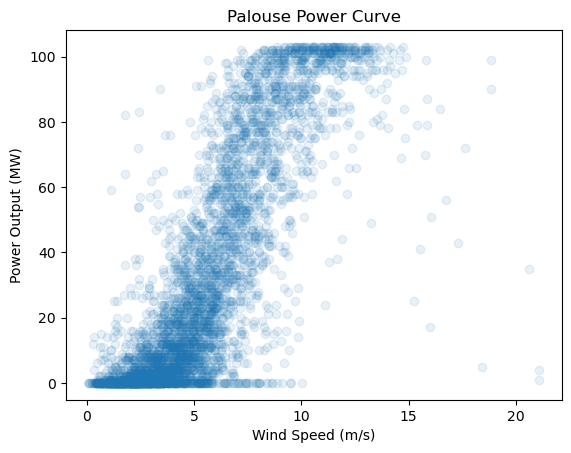

In [64]:
plt.scatter(eia['speed'], eia['power'], alpha=0.1)
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Power Output (MW)')
plt.title('Palouse Power Curve')

In [65]:
eia.to_csv('wevalidate_data/EIA_930.csv', index=False)

# Comparison of all EIA predictions

In [2]:
eia = pd.read_csv('wevalidate_data/EIA_930.csv')[['datetime', 'speed', 'power']]
nwpdb = pd.read_csv('wevalidate_data/nwpdb-HRRR.csv')[['time_stamp', 'power']]
pluswind = pd.read_csv('wevalidate_data/pluswind-HRRR.csv')[['time_stamp', 'power']]
trad = pd.read_csv('wevalidate_data/EIA_930_trad.csv')[['time_stamp', 'preds']]
prob = pd.read_csv('wevalidate_data/EIA_930_prob.csv')[['datetime', 'preds']]
rnn = pd.read_csv('wevalidate_data/EIA_930_168rnn_clamped.csv')[['time_stamp', 'preds']]

In [3]:
nwpdb['time_stamp'] = pd.to_datetime(nwpdb['time_stamp']).astype(str)
pluswind['time_stamp'] = pd.to_datetime(pluswind['time_stamp']).astype(str)

eia.rename(columns={'power': 'eia'}, inplace=True)
nwpdb.rename(columns={'time_stamp': 'datetime', 'power': 'nwpdb'}, inplace=True)
pluswind.rename(columns={'time_stamp': 'datetime', 'power': 'pluswind'}, inplace=True)
trad.rename(columns={'time_stamp': 'datetime', 'preds': 'trad'}, inplace=True)
prob.rename(columns={'preds': 'prob'}, inplace=True)
rnn.rename(columns={'time_stamp': 'datetime', 'preds': 'rnn'}, inplace=True)

In [4]:
palouse = pd.merge(eia, nwpdb, on='datetime')
palouse = pd.merge(palouse, pluswind, on='datetime')
palouse = pd.merge(palouse, trad, on='datetime')
palouse = pd.merge(palouse, prob, on='datetime')
palouse = pd.merge(palouse, rnn, on='datetime')

In [5]:
palouse

,datetime,speed,eia,nwpdb,pluswind,trad,prob,rnn
0,2018-07-01 05:00:00,8.061592,0,23.111913,54.127916,3.598997,7.400248e+01,45.631878
1,2018-07-01 06:00:00,9.478211,0,29.857634,89.440105,84.523151,1.003293e+02,58.317760
2,2018-07-01 07:00:00,10.042563,0,57.173356,99.027943,96.534595,1.031630e+02,72.821510
3,2018-07-01 08:00:00,9.480452,50,77.864366,89.510255,94.771520,9.938356e+01,53.849820
4,2018-07-01 09:00:00,9.033495,55,63.574595,76.721865,86.655028,9.372490e+01,62.087574
...,...,...,...,...,...,...,...,...
4406,2018-12-31 19:00:00,4.305253,7,18.960748,7.073032,21.143260,1.640157e-04,25.463665
4407,2018-12-31 20:00:00,2.721040,1,3.845769,0.000000,7.900082,2.050873e-04,24.353200
4408,2018-12-31 21:00:00,2.019171,2,0.000000,0.000000,3.980397,1.230518e-05,18.745539
4409,2018-12-31 22:00:00,1.126299,0,0.000000,0.000000,1.865024,5.309417e-14,1.339070


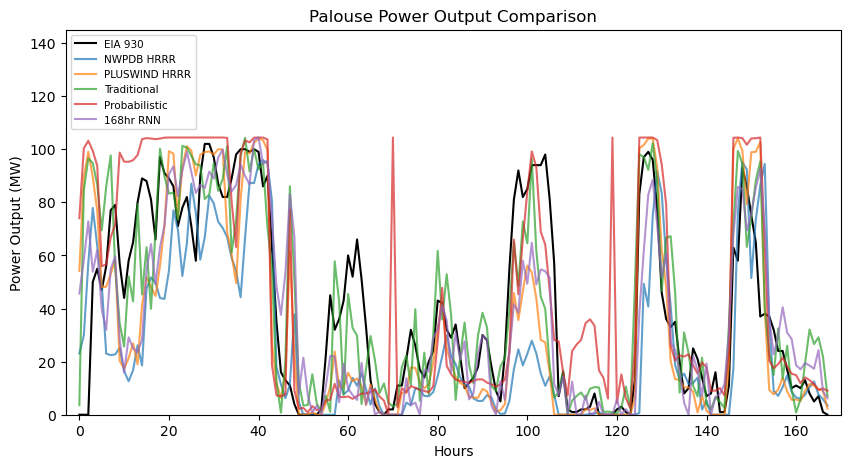

In [10]:
sub = palouse[:168].copy()
plt.figure(figsize=(10, 5))
plt.plot(sub['eia'], label='EIA 930', color='black')
plt.plot(sub['nwpdb'], label='NWPDB HRRR', alpha=0.7)
plt.plot(sub['pluswind'], label='PLUSWIND HRRR', alpha=0.7)
plt.plot(sub['trad'], label='Traditional', alpha=0.7)
plt.plot(sub['prob'], label='Probabilistic', alpha=0.7)
plt.plot(sub['rnn'], label='168hr RNN', alpha=0.7)
plt.xlabel('Hours')
plt.ylabel('Power Output (MW)')
plt.xlim(-3, 170)
plt.ylim(0, 145)
plt.title('Palouse Power Output Comparison')
plt.legend(fontsize=7.5, loc='upper left')

## power curve comparison with jensen shannon

In [18]:
def compute_similarity(true_power, pred_power):
    H_true, _, _ = np.histogram2d(palouse['speed'], true_power, bins=50)
    H_pred, _, _ = np.histogram2d(palouse['speed'], pred_power, bins=50)

    # normalize
    H_true_norm = H_true / H_true.sum()
    H_pred_norm = H_pred / H_pred.sum()

    js_div = jensenshannon(H_true_norm.flatten(), H_pred_norm.flatten())
    similarity = 1 - js_div

    return similarity, H_true_norm, H_pred_norm

In [22]:
similarity = compute_similarity(palouse['eia'], palouse['nwpdb'])
print(similarity[0])

0.5771684593804411


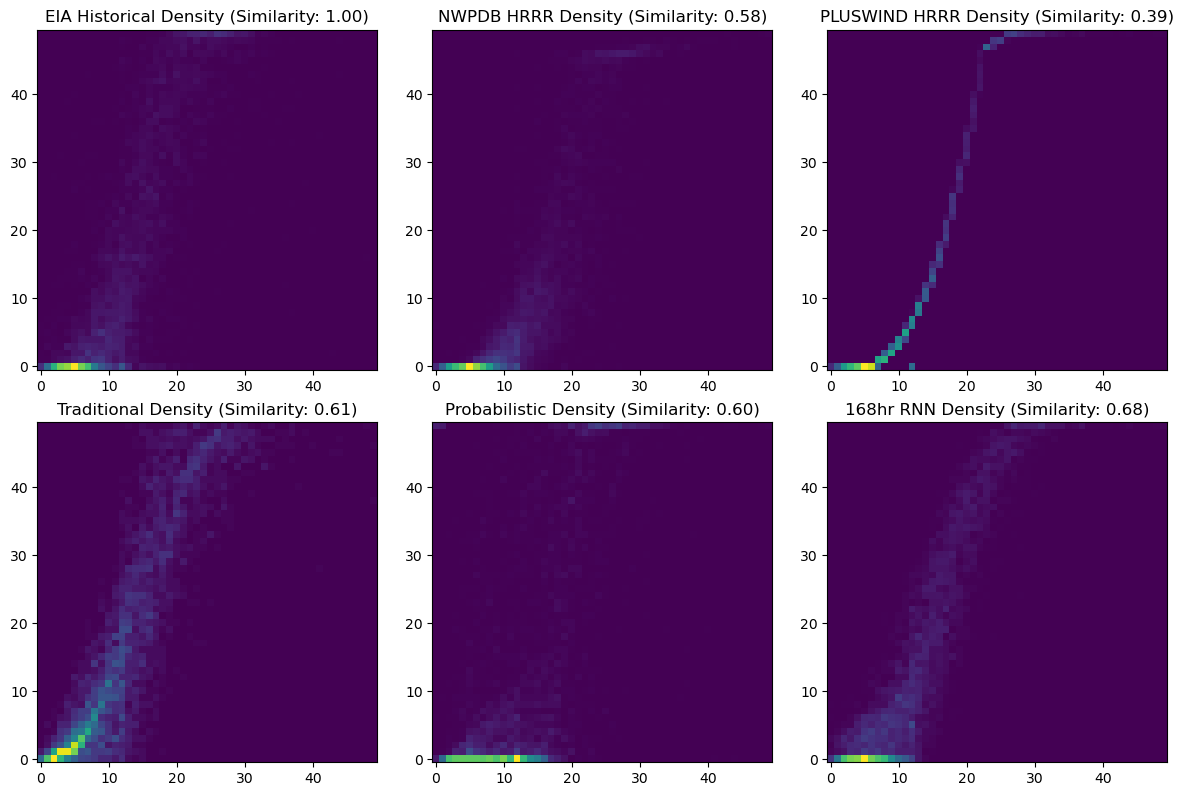

In [32]:
# compute similarities and plot densities
fig, axs = plt.subplots(2, 3, figsize=(12, 8))

cols = ['eia', 'nwpdb', 'pluswind', 'trad', 'prob', 'rnn']
titles = ['EIA Historical', 'NWPDB HRRR', 'PLUSWIND HRRR', 'Traditional', 'Probabilistic', '168hr RNN']
similarities = []
for ax, i in zip(axs.flat, range(len(cols))):
    similarity = compute_similarity(palouse['eia'], palouse[cols[i]])
    similarities.append(similarity[0])
    ax.imshow(similarity[2].T, origin='lower')
    ax.set_title(f"{titles[i]} Density (Similarity: {similarity[0]:.2f})", fontsize=12)

plt.tight_layout()

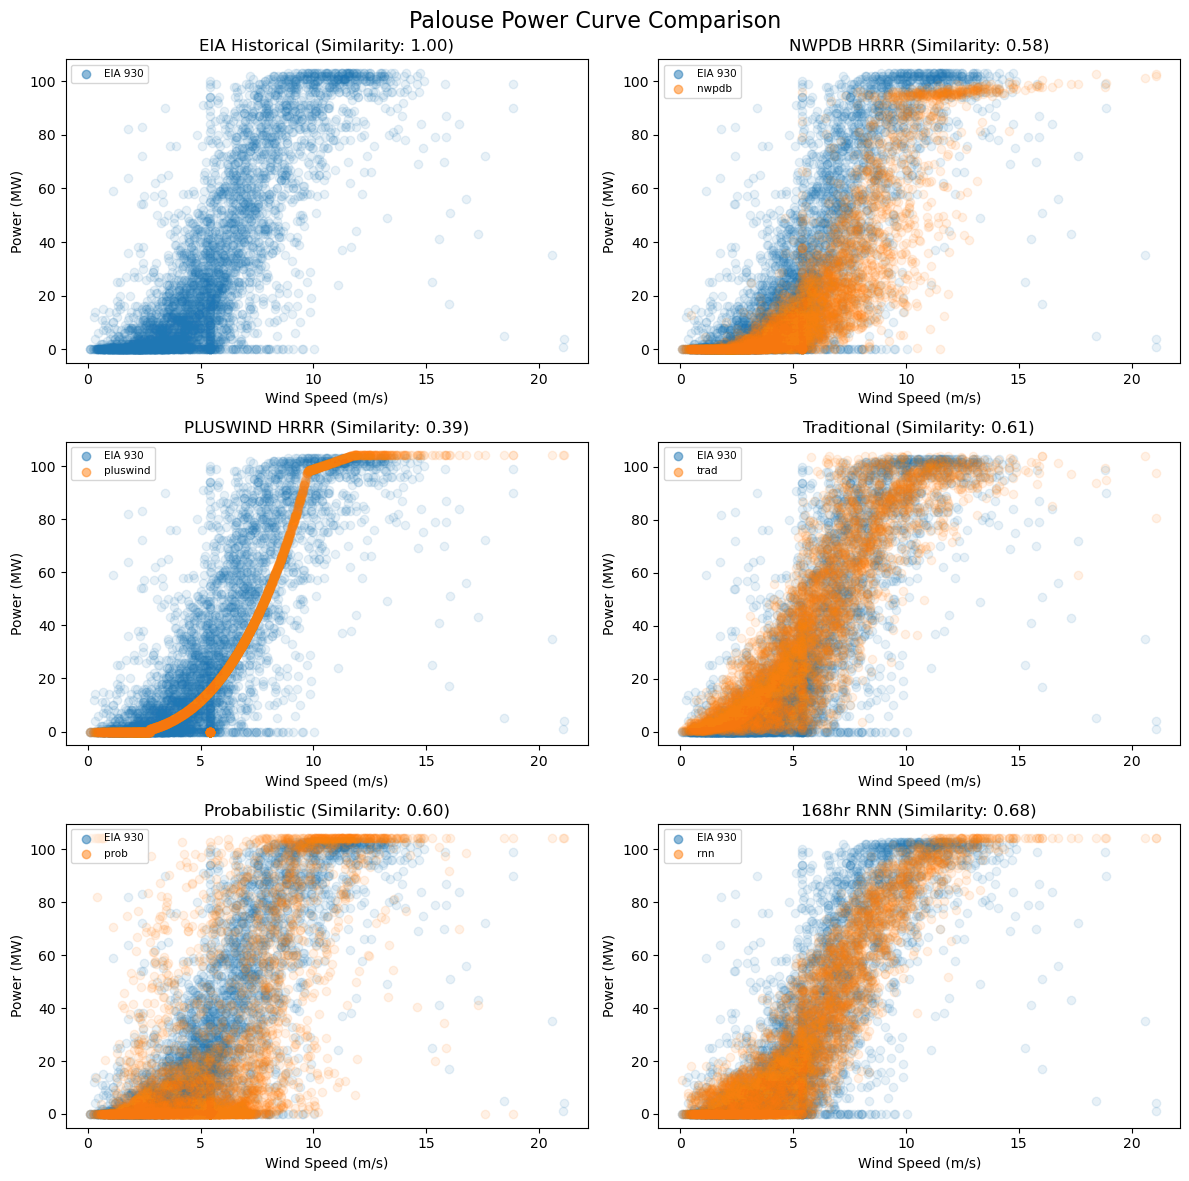

In [38]:
# power curve comparison
fig, axs = plt.subplots(3, 2, figsize=(12, 12))

cols = ['eia', 'nwpdb', 'pluswind', 'trad', 'prob', 'rnn']
titles = ['EIA Historical', 'NWPDB HRRR', 'PLUSWIND HRRR', 'Traditional', 'Probabilistic', '168hr RNN']
for ax, i in zip(axs.flat, range(len(cols))):
    ax.scatter(palouse['speed'], palouse['eia'], alpha=0.1, label='EIA 930')
    if i > 0:
        ax.scatter(palouse['speed'], palouse[cols[i]], alpha=0.1, label=cols[i])
    ax.set_xlabel('Wind Speed (m/s)')
    ax.set_ylabel('Power (MW)')
    ax.set_title(f"{titles[i]} (Similarity: {similarities[i]:.2f})", fontsize=12)
    leg = ax.legend(fontsize=7.5, loc='upper left')
    for leg in leg.legend_handles:
        leg.set_alpha(0.5)

plt.suptitle('Palouse Power Curve Comparison', fontsize=16)
plt.tight_layout()
# leg = plt.legend(fontsize=7.5, loc='upper left', bbox_to_anchor=(1.01, 1))
# for leg in leg.legend_handles:
#     leg.set_alpha(0.5)

# compute all similarities

In [39]:
eia = pd.read_csv('wevalidate_data/EIA_930.csv')[['datetime', 'speed', 'power']]
nwpdb = pd.read_csv('wevalidate_data/nwpdb-HRRR.csv')[['time_stamp', 'power']]
pluswind = pd.read_csv('wevalidate_data/pluswind-HRRR.csv')[['time_stamp', 'power']]
trad = pd.read_csv('wevalidate_data/EIA_930_trad.csv')[['time_stamp', 'preds']]
prob = pd.read_csv('wevalidate_data/EIA_930_prob.csv')[['datetime', 'preds']]
rnn = pd.read_csv('wevalidate_data/EIA_930_rnn.csv')[['time_stamp', 'preds_24hr', 'preds_168hr']]
rnn168_clamped = pd.read_csv('wevalidate_data/EIA_930_168rnn_clamped.csv')[['time_stamp', 'preds']]

In [40]:
nwpdb['time_stamp'] = pd.to_datetime(nwpdb['time_stamp']).astype(str)
pluswind['time_stamp'] = pd.to_datetime(pluswind['time_stamp']).astype(str)

eia.rename(columns={'power': 'eia'}, inplace=True)
nwpdb.rename(columns={'time_stamp': 'datetime', 'power': 'nwpdb'}, inplace=True)
pluswind.rename(columns={'time_stamp': 'datetime', 'power': 'pluswind'}, inplace=True)
trad.rename(columns={'time_stamp': 'datetime', 'preds': 'trad'}, inplace=True)
prob.rename(columns={'preds': 'prob'}, inplace=True)
rnn.rename(columns={'time_stamp': 'datetime', 'preds_24hr': 'rnn_24hr', 'preds_168hr': 'rnn_168hr'}, inplace=True)
rnn168_clamped.rename(columns={'time_stamp': 'datetime', 'preds': 'rnn_168hr_clamped'}, inplace=True)

In [41]:
palouse = pd.merge(eia, nwpdb, on='datetime')
palouse = pd.merge(palouse, pluswind, on='datetime')
palouse = pd.merge(palouse, trad, on='datetime')
palouse = pd.merge(palouse, prob, on='datetime')
palouse = pd.merge(palouse, rnn, on='datetime')
palouse = pd.merge(palouse, rnn168_clamped, on='datetime')

In [45]:
cols = ['eia', 'nwpdb', 'pluswind', 'trad', 'prob', 'rnn_24hr', 'rnn_168hr', 'rnn_168hr_clamped']
similarities = []
for col in cols:
    similarity = compute_similarity(palouse['eia'], palouse[col])
    similarities.append(similarity[0])
for col, sim in zip(cols, similarities):
    print(f"{col}: {sim:.3f}")

eia: 1.000
nwpdb: 0.577
pluswind: 0.395
trad: 0.607
prob: 0.601
rnn_24hr: 0.415
rnn_168hr: 0.463
rnn_168hr_clamped: 0.680


# power curve comparison with 14-23 data

In [49]:
trad = pd.read_csv('results/trad_1423.csv')[['time_stamp', 'speed', 'power', 'preds']].rename(columns={'preds': 'trad'})
prob = pd.read_csv('results/prob_1423.csv')[['time_stamp', 'preds']].rename(columns={'preds': 'prob'})
rnn = pd.read_csv('results/rnn_168hr_1423.csv')[['time_stamp', 'preds']].rename(columns={'preds': 'rnn'})

In [51]:
merged = pd.merge(trad, prob, on='time_stamp')
merged = pd.merge(merged, rnn, on='time_stamp')

In [52]:
merged

,time_stamp,speed,power,trad,prob,rnn
0,2014-07-30 12:00:00,9.416307,222.814,137.755872,145.092227,125.620760
1,2014-07-30 13:00:00,8.168459,193.077,87.264975,120.531092,100.206474
2,2014-07-30 14:00:00,6.081183,166.707,54.894012,71.752208,57.116850
3,2014-07-30 15:00:00,3.644644,135.965,38.411378,12.489751,27.820590
4,2014-07-30 16:00:00,4.062179,103.724,21.868490,22.720655,0.000000
...,...,...,...,...,...,...
82295,2023-12-19 11:00:00,10.002887,14.636,184.907096,106.454807,114.404430
82296,2023-12-19 12:00:00,9.850973,5.243,137.147763,102.914333,93.983800
82297,2023-12-19 13:00:00,9.078698,0.446,173.734671,85.056663,74.867714
82298,2023-12-19 14:00:00,8.771991,0.195,171.832568,79.220808,136.012920


In [59]:
def compute_similarity(true_power, pred_power):
    H_true, _, _ = np.histogram2d(merged['speed'], true_power, bins=50)
    H_pred, _, _ = np.histogram2d(merged['speed'], pred_power, bins=50)

    # normalize
    H_true_norm = H_true / H_true.sum()
    H_pred_norm = H_pred / H_pred.sum()

    js_div = jensenshannon(H_true_norm.flatten(), H_pred_norm.flatten())
    similarity = 1 - js_div

    return similarity, H_true_norm, H_pred_norm

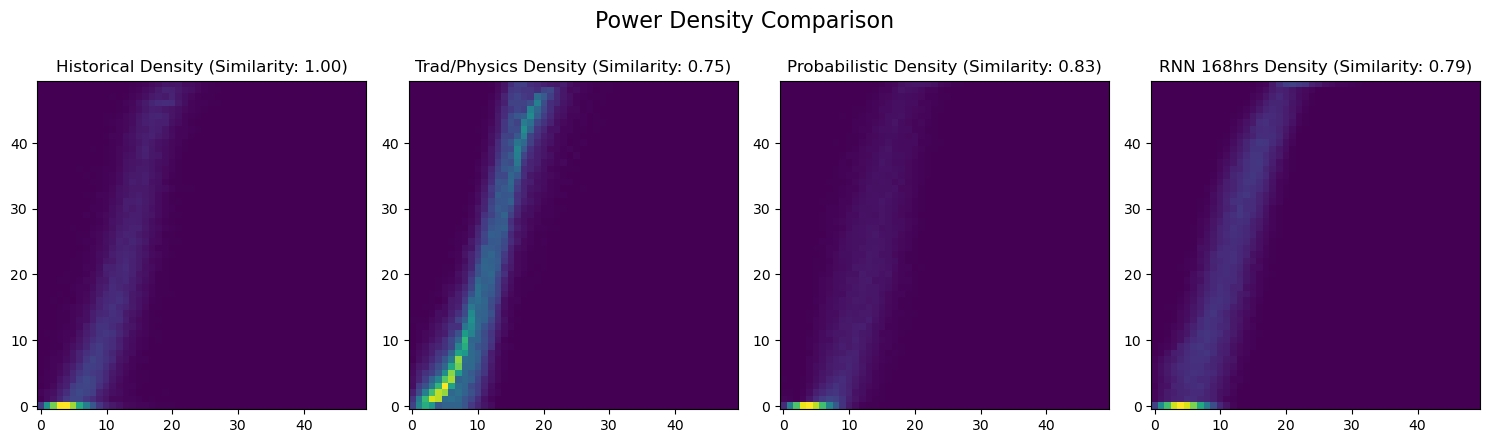

In [73]:
# compute similarities and plot densities
fig, axs = plt.subplots(1, 4, figsize=(15, 4.5))

cols = ['power', 'trad', 'prob', 'rnn']
titles = ['Historical', 'Trad/Physics', 'Probabilistic', 'RNN 168hrs']
similarities = []
for ax, i in zip(axs.flat, range(len(cols))):
    similarity = compute_similarity(merged['power'], merged[cols[i]])
    similarities.append(similarity[0])
    ax.imshow(similarity[2].T, origin='lower')
    ax.set_title(f"{titles[i]} Density (Similarity: {similarity[0]:.2f})", fontsize=12)

fig.suptitle('Power Density Comparison', fontsize=16)
fig.tight_layout()

# covariance with prices

In [78]:
df = pd.read_csv('../../data/processed/dataset_2018-21_withloads_power.csv').drop(columns=['Unnamed: 0', 'user_load_zonal', 'power_cf'])
trad = pd.read_csv('results/trad_physics_approach.csv')[['time_stamp', 'preds']].rename(columns={'time_stamp': 'datetime', 'preds': 'trad'})
prob = pd.read_csv('results/prob_sample_approach.csv')[['time_stamp', 'preds']].rename(columns={'time_stamp': 'datetime', 'preds': 'prob'})
rnn = pd.read_csv('results/rnn_168hr.csv')[['time_stamp', 'preds']].rename(columns={'time_stamp': 'datetime', 'preds': 'rnn'})

In [79]:
merged = pd.merge(df, trad, on='datetime')
merged = pd.merge(merged, prob, on='datetime')
merged = pd.merge(merged, rnn, on='datetime')

In [80]:
merged

,datetime,speed,lmp,power,trad,prob,rnn
0,2018-01-01 01:00:00,6.384246,27.721667,134.039,47.792803,5.739404e-01,119.736470
1,2018-01-01 02:00:00,6.679563,27.409167,123.450,81.397156,6.017519e-01,94.574844
2,2018-01-01 03:00:00,6.784414,27.933333,116.143,61.163203,6.869195e-01,94.784836
3,2018-01-01 04:00:00,6.794198,28.816667,94.625,34.449016,1.479091e+00,38.709515
4,2018-01-01 05:00:00,7.114358,31.992500,41.765,33.327235,2.924868e+00,26.089851
...,...,...,...,...,...,...,...
34650,2021-12-23 04:00:00,10.159357,20.996667,4.206,4.856703,2.904280e-10,25.710924
34651,2021-12-23 05:00:00,10.173759,16.511667,95.699,0.375069,2.470639e-17,-8.147799
34652,2021-12-23 06:00:00,10.686074,13.153333,98.267,17.500533,6.622263e-03,-3.748298
34653,2021-12-23 07:00:00,10.655013,19.105000,99.595,23.486273,7.729457e-01,3.389787


In [82]:
np.cov(merged['power'], merged['lmp'])[0, 1]

-1497.3069071451175

In [91]:
lmp = [1000 if x > 1000 else x for x in merged['lmp']]

In [100]:
np.array(lmp[:200])

array([27.72166667, 27.40916667, 27.93333333, 28.81666667, 31.9925    ,
       35.41083333, 36.93583333, 40.1525    , 41.73583333, 42.4475    ,
       41.85      , 37.73083333, 33.03166667, 29.89416667, 29.845     ,
       31.5675    , 40.14333333, 45.685     , 44.93666667, 43.17833333,
       38.18083333, 35.16      , 28.91916667, 27.64      , 27.48666667,
       27.1025    , 27.31333333, 28.085     , 30.34333333, 37.74916667,
       41.78416667, 44.17416667, 46.15333333, 49.4475    , 48.645     ,
       45.495     , 44.22666667, 44.74916667, 41.02      , 44.32166667,
       56.46583333, 53.15916667, 53.78583333, 55.65      , 41.62      ,
       32.86333333, 28.63416667, 34.78333333, 33.8525    , 32.75416667,
       34.65166667, 38.71666667, 45.88      , 53.61333333, 51.89583333,
       53.13416667, 69.73      , 66.88      , 57.17166667, 49.64916667,
       44.1025    , 41.95333333, 43.16333333, 51.2925    , 65.89083333,
       65.95166667, 67.54666667, 55.43666667, 51.46166667, 49.94

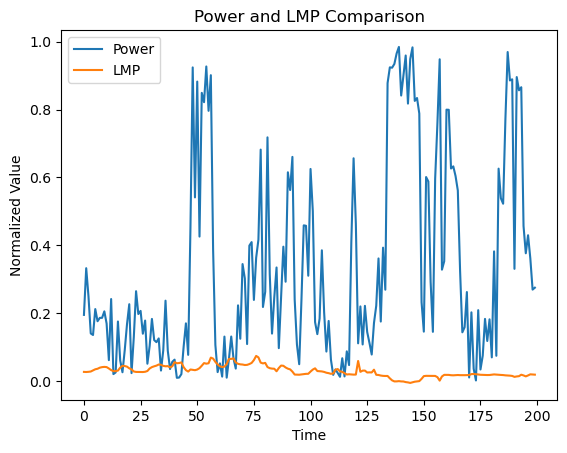

In [102]:
plt.plot(merged['trad'][:200]/max(merged['trad']), label='Power')
plt.plot(np.array(lmp[:200])/max(lmp), label='LMP')
plt.xlabel('Time')
plt.ylabel('Normalized Value')
plt.title('Power and LMP Comparison')
plt.legend()
plt.show()

In [85]:
np.cov(merged['rnn'], merged['lmp'])[0, 1]

375.6466138878411